In [1]:
from langchain_ollama import ChatOllama

model = ChatOllama(model="gpt-oss:120b-cloud")
print('Model is ready')


c:\Users\ak60492\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Model is ready


In [2]:
from langchain_community.tools import tool

@tool
def get_weather(city: str) -> str:
    """Get weather for a city"""
    return f"The weather in the city {city} is Sunny"

@tool
def get_stock_price(stock: str) -> str:
    """Returns the stock price for a given stock"""
    return f"The stock price of {stock} is 25.50"

print('Tools are ready')

Tools are ready


In [3]:
# STEP 1 - Define the central state of the application
from typing import Annotated, TypedDict
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

print('Graph State is ready')


Graph State is ready


In [ ]:
# STEP 2 - Define your nodes
def assistant(state:AgentState) -> dict:
    """One graph node: call the LLM using current messages."""
    response = model.invoke(state['messages'])
    return {"messages": [response]}

def assistant_2(state:AgentState) -> dict:
    """One graph node: call the LLM using current messages."""
    response = model.invoke(state['messages'])
    return {"messages": [response]}


Simpl graph is ready


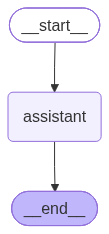

In [5]:
# STEP 3 - Bind nodes together using Edges
from langgraph.graph import StateGraph, START, END

simple_graph_builder = StateGraph(AgentState)

# Node registration
simple_graph_builder.add_node("assistant", assistant)

# Add edges to nodes
simple_graph_builder.add_edge(START, "assistant")
simple_graph_builder.add_edge("assistant", END)

simple_graph = simple_graph_builder.compile()
print('Simpl graph is ready')
simple_graph

In [6]:
response = simple_graph.invoke({
    "messages": [
        {"role": "user", "content": "I am Anand"}
    ]
})

response

{'messages': [HumanMessage(content='I am Anand', additional_kwargs={}, response_metadata={}, id='aeba6b2f-dc44-4aa0-ae62-08b2838b0858'),
  AIMessage(content='Hello Anand! 👋 It’s great to meet you. How can I assist you today? Whether you have a question, need help with something, or just want to chat, I’m here for you. Let me know what’s on your mind!', additional_kwargs={}, response_metadata={'model': 'gpt-oss:120b', 'created_at': '2026-09-21T04:02:04.016627807Z', 'done': True, 'done_reason': 'stop', 'total_duration': 431290594, 'load_duration': None, 'prompt_eval_count': 70, 'prompt_eval_duration': None, 'eval_count': 110, 'eval_duration': None, 'logprobs': None, 'model_name': 'gpt-oss:120b', 'model_provider': 'ollama'}, id='lc_run--01a0c220-c634-73e1-b624-bd1522c27409-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 70, 'output_tokens': 110, 'total_tokens': 180})]}

In [7]:
response = simple_graph.invoke({
    "messages": [
        {"role": "user", "content": "What is my name?"}
    ]
})

response

{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='08033c5b-df53-43d1-b2dd-9d3cddc84ec7'),
  AIMessage(content='I’m not sure what your name is—could you remind me?', additional_kwargs={}, response_metadata={'model': 'gpt-oss:120b', 'created_at': '2026-09-21T04:02:36.617353803Z', 'done': True, 'done_reason': 'stop', 'total_duration': 503325991, 'load_duration': None, 'prompt_eval_count': 72, 'prompt_eval_duration': None, 'eval_count': 64, 'eval_duration': None, 'logprobs': None, 'model_name': 'gpt-oss:120b', 'model_provider': 'ollama'}, id='lc_run--01a0c221-432c-7c73-89ec-ac0b8a1f0b1e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 64, 'total_tokens': 136})]}

In [13]:
from langgraph.checkpoint.memory import MemorySaver
from langchain.agents import create_agent

short_term_memory = MemorySaver()
agent = create_agent(model=model, tools=[], checkpointer=short_term_memory)
print('agent created with short term memory')

agent created with short term memory


In [15]:
config = {"configurable": {"thread_id": "jobs_as_ai_developer"}}
response = agent.invoke({
    "messages": [
        {"role": "user", "content": "I am Anand"}
    ]
},
config=config
)

print(f'Response 1: {response['messages'][-1].content}')

response = agent.invoke({
    "messages": [
        {"role": "user", "content": "What is my name?"}
    ]
},
config=config
)

print(f'Response 2: {response['messages'][-1].content}')

Response 1: Hey Anand! 👋 Great to meet you. How’s your day going? Anything on your mind that you’d like to chat about or get help with? Feel free to share—whether it’s a question, a project, a curiosity, or just a friendly conversation. I’m here for you!
Response 2: Your name is Anand. 🌟


In [18]:
# Short term memory in the RAM
from langgraph.checkpoint.memory import MemorySaver
# Short term memory in the database sqllite
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3

db_path = "conversation_memory.db"
sqllite_connection = sqlite3.connect(db_path, check_same_thread=False)
sqllite_checkpointer = SqliteSaver(sqllite_connection)

agent = create_agent(model=model, tools=[], checkpointer=sqllite_checkpointer)
print('agent created with short term memory sqllite')


agent created with short term memory sqllite


In [ ]:
config = {"configurable": {"thread_id": "jobs_as_ai_developer"}}
response = agent.invoke({
    "messages": [
        {"role": "user", "content": "I am Anand"}
    ]
},
config=config
)

print(f'Response 1: {response['messages'][-1].content}')

response = agent.invoke({
    "messages": [
        {"role": "user", "content": "What is my name?"}
    ]
},
config=config
)

print(f'Response 2: {response['messages'][-1].content}')

Response 1: Nice to meet you, Anand! How can I assist you today?
Response 2: I don’t know your name—unless you’d like to share it with me, I can’t guess it. If you tell me what you’d like to be called, I’ll be happy to use that name in our conversation!


In [ ]:
from langgraph.config import get_store, get_config

@tool
def save_memory(fact: str) -> str:
    """Save an important fact about the user for future conversations
    (e.g. their name, workplace, or a stated preference)."""
    store = get_store()
    user_id = get_config()["configurable"]["user_id"]
    store.put(("memories", user_id), fact[:40], {"text": fact})
    return f"Saved: {fact}"

@tool
def recall_memories(query: str) -> str:
    """Search saved facts about the user relevant to the query.
    ALWAYS call this before claiming you don't know something about the user."""
    store = get_store()
    user_id = get_config()["configurable"]["user_id"]
    results = store.search(("memories", user_id), query=query, limit=5)
    if not results:
        return "No relevant memories found."
    return "\n".join(f"- {r.value['text']}" for r in results)

print("Memory tools ready: save_memory, recall_memories")


Memory tools ready: save_memory, recall_memories


In [ ]:
from langgraph.store.memory import InMemoryStore
from langgraph.store.sqlite import SqliteStore

# long_term_memory = SqliteStore() # in database
long_term_memory = InMemoryStore() # in RAM

from langchain.agents import create_agent

agent = create_agent(model=model, tools=[save_memory, recall_memories], 
                     store=long_term_memory,
    system_prompt=(
        "You are a helpful assistant with long-term memory. "
        "When the user shares a personal fact, call save_memory, then briefly confirm. "
        "When asked what you know about the user, ALWAYS call recall_memories first. "
        "Your final answer MUST be based only on the tool output returned -- restate those facts plainly. "
        "Never say you don't know something if the tool result contains it."
    )
)
print('agent created with long term memory')

agent created with long term memory


In [31]:
config = {"configurable": {"thread_id": "jobs_as_ai_developer", "user_id": "user_tom"}}
config_2 = {"configurable": {"thread_id": "global_warming", "user_id": "user_tom"}}
response = agent.invoke({
    "messages": [
        {"role": "user", "content": "I am Anand"}
    ]
},
config=config
)

print(f'Response 1: {response['messages'][-1].content}')

response = agent.invoke({
    "messages": [
        {"role": "user", "content": "What is my name?"}
    ]
},
config=config_2
)

print(f'Response 2: {response['messages'][-1].content}')

save_memory -> user_d: user_tom
save_memory -> fact: User's name is Anand
Response 1: Got it, Anand! Let me know how I can help you today.
Response 2: Your name is Anand.


In [ ]:
config = {"configurable": {"thread_id": "jobs_as_ai_developer", "user_id": "user_tom"}}
config_2 = {"configurable": {"thread_id": "global_warming", "user_id": "user_jerry"}}
response = agent.invoke({
    "messages": [
        {"role": "user", "content": "I am Anand"}
    ]
},
config=config
)

print(f'Response 1: {response['messages'][-1].content}')

response = agent.invoke({
    "messages": [
        {"role": "user", "content": "What is my name?"}
    ]
},
config=config_2
)

print(f'Response 2: {response['messages'][-1].content}')

save_memory -> user_d: user_tom
save_memory -> fact: User name is Anand
Response 1: Got it! I’ve noted that your name is Anand.
Response 2: I’m sorry, but I don’t have any record of your name.
